# Chordonomicon — Dataset Exploration

Basic exploration of the [Chordonomicon](https://huggingface.co/datasets/ailsntua/Chordonomicon) dataset  
(Kantarelis et al., arXiv:2410.22046, 2024 — 666 k songs with chord progressions).

We stream a sample so cells re-run in seconds. Raise `N_SAMPLE` for more precise statistics.

In [ ]:
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datasets import load_dataset

# Locate project root (contains pyproject.toml) and add it + scripts/ to sys.path
_ROOT = Path.cwd()
while not (_ROOT / "pyproject.toml").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
if str(_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(_ROOT / "scripts"))

_DATA_DIR = _ROOT / "data"

from fit_transition_matrix import (
    parse_chord_root,
    infer_key,
    strip_structural_tags,
    extract_section,
    extract_section_instances,
    minimal_repeating_unit,
    chord_to_degree,
    accumulate_song,
    NOTES,
)
from stochastic_strategies.strategy import entropy_rate, stationary_distribution

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

DEGREE_NAMES = ["I", "II", "III", "IV", "V", "VI", "VII"]

## Load sample

In [ ]:
N_SAMPLE = 5_000

print(f"Streaming first {N_SAMPLE:,} songs…")
ds = load_dataset("ailsntua/Chordonomicon", split="train", streaming=True)
df = pd.DataFrame(ds.take(N_SAMPLE))
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")
df.head(3)

Streaming first 5,000 songs…
Loaded 5,000 rows × 10 columns


,id,chords,release_date,genres,decade,rock_genre,artist_id,main_genre,spotify_song_id,spotify_artist_id
0,1,<intro_1> C <verse_1> F C E7 Amin C F C G7 C F...,None,'classic country pop',NaN,None,artist_1,pop,None,4AIEGdwDzPELXYgM5JaEY5
1,2,<intro_1> E D A/Cs E D A/Cs <verse_1> E D A/Cs...,2003-01-01,'alternative metal' 'alternative rock' 'nu met...,2000.0,pop rock,artist_2,metal,2ffJZ2r8HxI5DHcmf3BO6c,694QW15WkebjcrWgQHzRYF
2,3,<intro_1> Csmin <verse_1> A Csmin A Csmin A Cs...,2003-01-01,'alternative metal' 'canadian rock' 'funk meta...,2000.0,canadian rock,artist_3,metal,5KiY8SZEnvCPyIEkFGRR3y,0niJkG4tKkne3zwr7I8n9n


## Schema & null counts

In [ ]:
print(df.dtypes)
print()
null_pct = df.isnull().mean().mul(100).round(1)
print(null_pct.rename("null %").to_string())

id                     int64
chords                object
release_date          object
genres                object
decade               float64
rock_genre            object
artist_id             object
main_genre            object
spotify_song_id       object
spotify_artist_id     object
dtype: object

id                    0.0
chords                0.0
release_date         23.9
genres               32.9
decade               23.9
rock_genre           82.0
artist_id            10.5
main_genre           46.9
spotify_song_id      21.6
spotify_artist_id    10.5


## Genre distribution

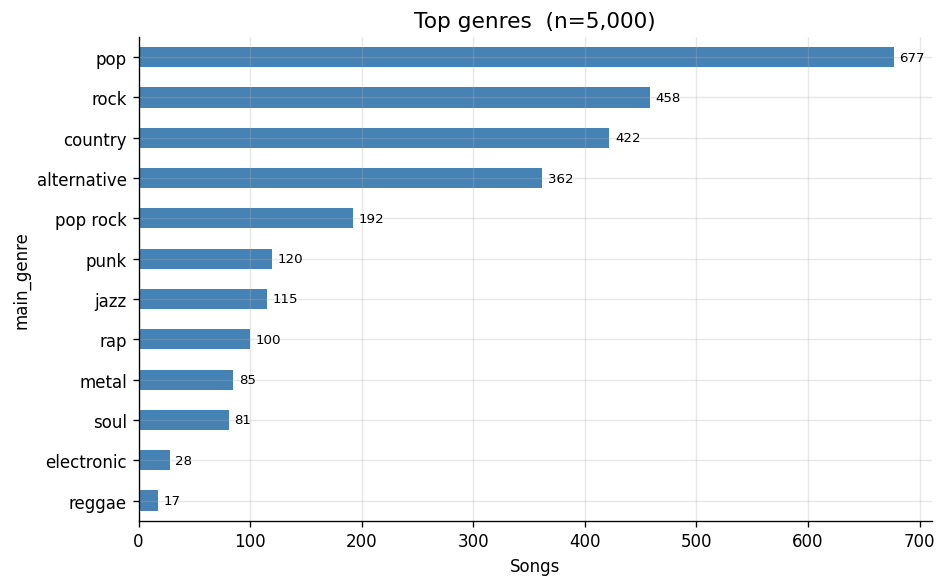

In [ ]:
genre_counts = df["main_genre"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
genre_counts.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title(f"Top genres  (n={N_SAMPLE:,})", fontsize=13)
ax.set_xlabel("Songs")
for bar in ax.patches:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## Decade distribution

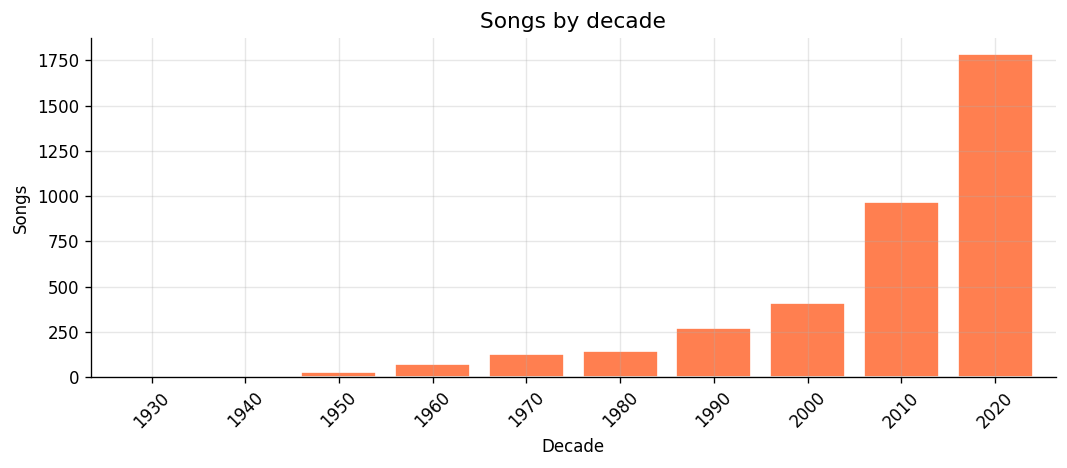

In [ ]:
decade_counts = (
    df["decade"].dropna().astype(int).value_counts().sort_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
decade_counts.plot.bar(ax=ax, color="coral", edgecolor="white", width=0.8)
ax.set_title("Songs by decade", fontsize=13)
ax.set_xlabel("Decade")
ax.set_ylabel("Songs")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Section types

Chordonomicon encodes structure as inline tags like `<chorus_1>`, `<verse_2>`, etc.  
We strip the numeric suffix and count how many songs contain each section type.

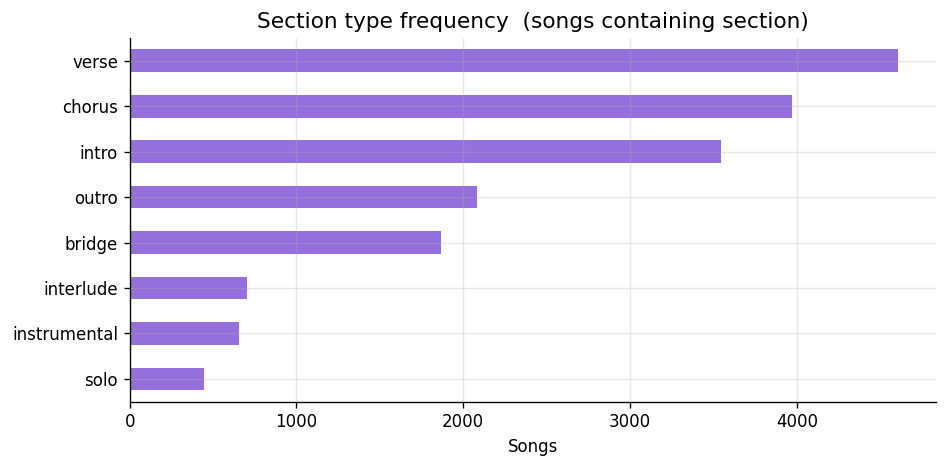

verse           4604
chorus          3969
intro           3543
outro           2082
bridge          1864
interlude        701
instrumental     658
solo             446


In [ ]:
def base_section_types(chord_string: str) -> set[str]:
    tags = re.findall(r'<([^>]+)>', chord_string)
    return {re.sub(r'_\d+$', '', t.lower()) for t in tags}

section_counts = Counter()
for cs in df["chords"].dropna():
    for s in base_section_types(cs):
        section_counts[s] += 1

section_s = pd.Series(section_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
section_s.head(12).sort_values().plot.barh(ax=ax, color="mediumpurple")
ax.set_title("Section type frequency  (songs containing section)", fontsize=13)
ax.set_xlabel("Songs")
plt.tight_layout()
plt.show()

print(section_s.head(12).to_string())

## Chorus progression length distribution

Number of unique diatonic chords per **chorus** section (consecutive duplicates collapsed, chromatic chords excluded).  
This is the same length measure used at runtime to sample how many chords to generate — length statistics are chorus-only throughout.

In [ ]:
def diatonic_length(chord_string: str) -> int | None:
    """Length of the minimal repeating unit of the first chorus instance."""
    instances = extract_section_instances(chord_string, "chorus")
    if not instances:
        return None
    tokens = instances[0]
    key = infer_key(tokens)
    if key is None:
        return None
    degrees, prev_root = [], None
    for t in tokens:
        root = parse_chord_root(t)
        if root is None or root == prev_root:
            continue
        if chord_to_degree(root, key) is not None:
            degrees.append(root)
        prev_root = root
    degrees = minimal_repeating_unit(degrees)
    return len(degrees) if degrees else None

lengths = df["chords"].dropna().map(diatonic_length).dropna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lengths.clip(upper=32).plot.hist(
    ax=axes[0], bins=32, color="teal", edgecolor="white"
)
axes[0].set_title("Chorus loop length — minimal repeating unit  (capped 32)", fontsize=12)
axes[0].set_xlabel("Unique diatonic chords in loop")
axes[0].set_ylabel("Songs")

lengths[lengths <= 16].plot.hist(
    ax=axes[1], bins=16, color="teal", edgecolor="white"
)
axes[1].set_title("Zoom: loop lengths 1 – 16", fontsize=12)
axes[1].set_xlabel("Unique diatonic chords in loop")

plt.tight_layout()
plt.show()

print(lengths.describe().round(2))
print(f"\nMode: {lengths.mode()[0]} chords")
print(f"Median: {lengths.median():.0f} chords")

### Saved chorus length distribution

The bar chart below shows the empirical chorus-length distribution serialized to `transition_matrix_lengths.npy` by `fit_transition_matrix.py` (run with `--section chorus`, the default). This is the exact distribution sampled at runtime to decide how many chords to generate.

In [ ]:
len_path = _DATA_DIR / "transition_matrix_lengths.npy"
if len_path.exists():
    saved_dist = np.load(len_path)
    n_bins = len(saved_dist)
    x = np.arange(1, n_bins + 1)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(x, saved_dist, color="teal", edgecolor="white", alpha=0.85)

    mode_len = int(np.argmax(saved_dist)) + 1
    mean_len = float((x * saved_dist).sum())
    ax.axvline(mode_len, color="coral", ls="--", lw=2, label=f"Mode = {mode_len}")
    ax.axvline(mean_len, color="steelblue", ls="--", lw=2, label=f"Mean = {mean_len:.1f}")

    ax.set_title("Chorus length distribution  (data/transition_matrix_lengths.npy)", fontsize=12)
    ax.set_xlabel("Diatonic chords in chorus")
    ax.set_ylabel("Probability")
    ax.set_xlim(0, min(n_bins + 1, 33))
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Distribution covers lengths 1–{n_bins}")
    print(f"Mode: {mode_len} chords   Mean: {mean_len:.1f} chords")
    print(f"P(length ≤  4): {saved_dist[:4].sum():.1%}")
    print(f"P(length ≤  8): {saved_dist[:8].sum():.1%}")
    print(f"P(length ≤ 16): {saved_dist[:16].sum():.1%}")
else:
    print(f"'{len_path}' not found — run `python scripts/fit_transition_matrix.py` to generate it.")

## Most common chord roots

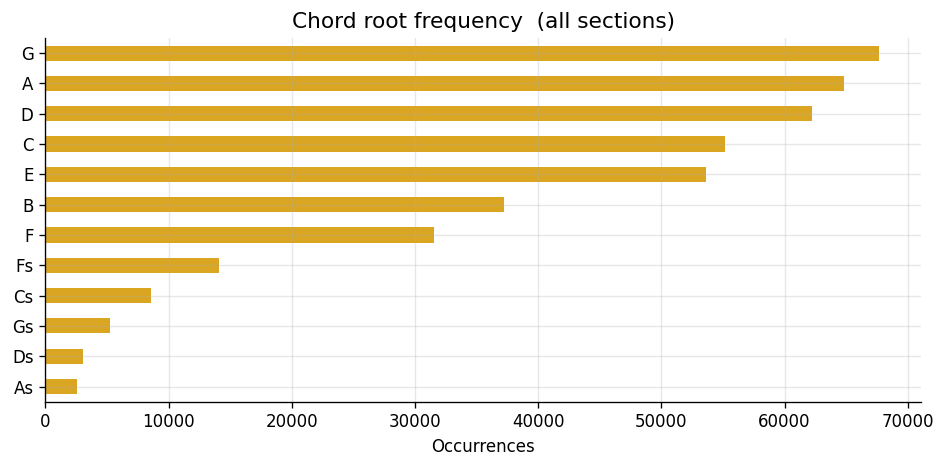

In [ ]:
root_counts = Counter()
for cs in df["chords"].dropna():
    for t in strip_structural_tags(cs):
        root = parse_chord_root(t)
        if root is not None:
            root_counts[NOTES[root]] += 1

root_s = pd.Series(root_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
root_s.sort_values().plot.barh(ax=ax, color="goldenrod")
ax.set_title("Chord root frequency  (all sections)", fontsize=13)
ax.set_xlabel("Occurrences")
plt.tight_layout()
plt.show()

## Inferred key distribution

Key is inferred via maximum diatonic coverage (Temperley-style), the same method used in `fit_transition_matrix.py`.

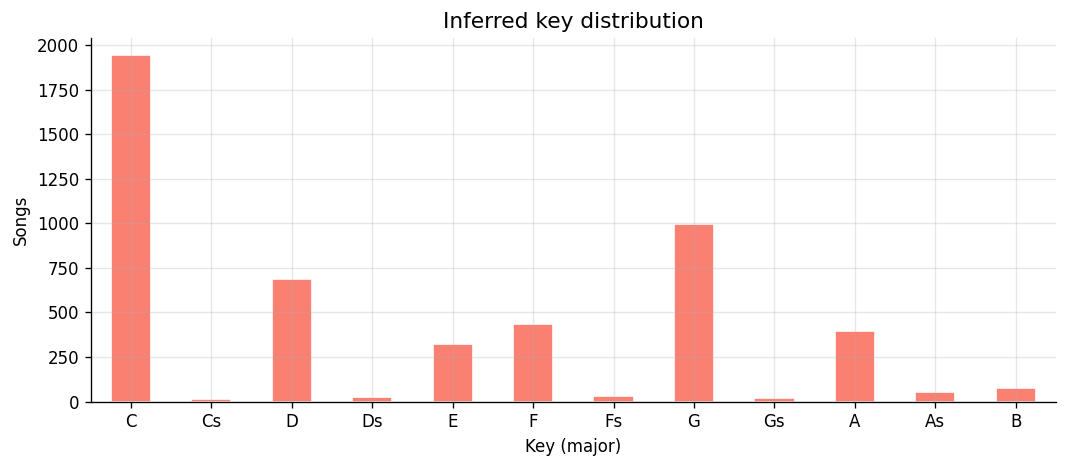

In [ ]:
def inferred_key_name(chord_string: str) -> str | None:
    tokens = strip_structural_tags(chord_string)
    idx = infer_key(tokens)
    return NOTES[idx] if idx is not None else None

key_counts = df["chords"].dropna().map(inferred_key_name).value_counts()
key_counts = key_counts.reindex(
    [n for n in NOTES if n in key_counts.index]
)

fig, ax = plt.subplots(figsize=(9, 4))
key_counts.plot.bar(ax=ax, color="salmon", edgecolor="white")
ax.set_title("Inferred key distribution", fontsize=13)
ax.set_xlabel("Key (major)")
ax.set_ylabel("Songs")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Chord root frequency by inferred key

A heatmap showing which chord roots appear most often within each inferred key —  
lets you see whether the diatonic degrees follow the expected pop/rock pattern.

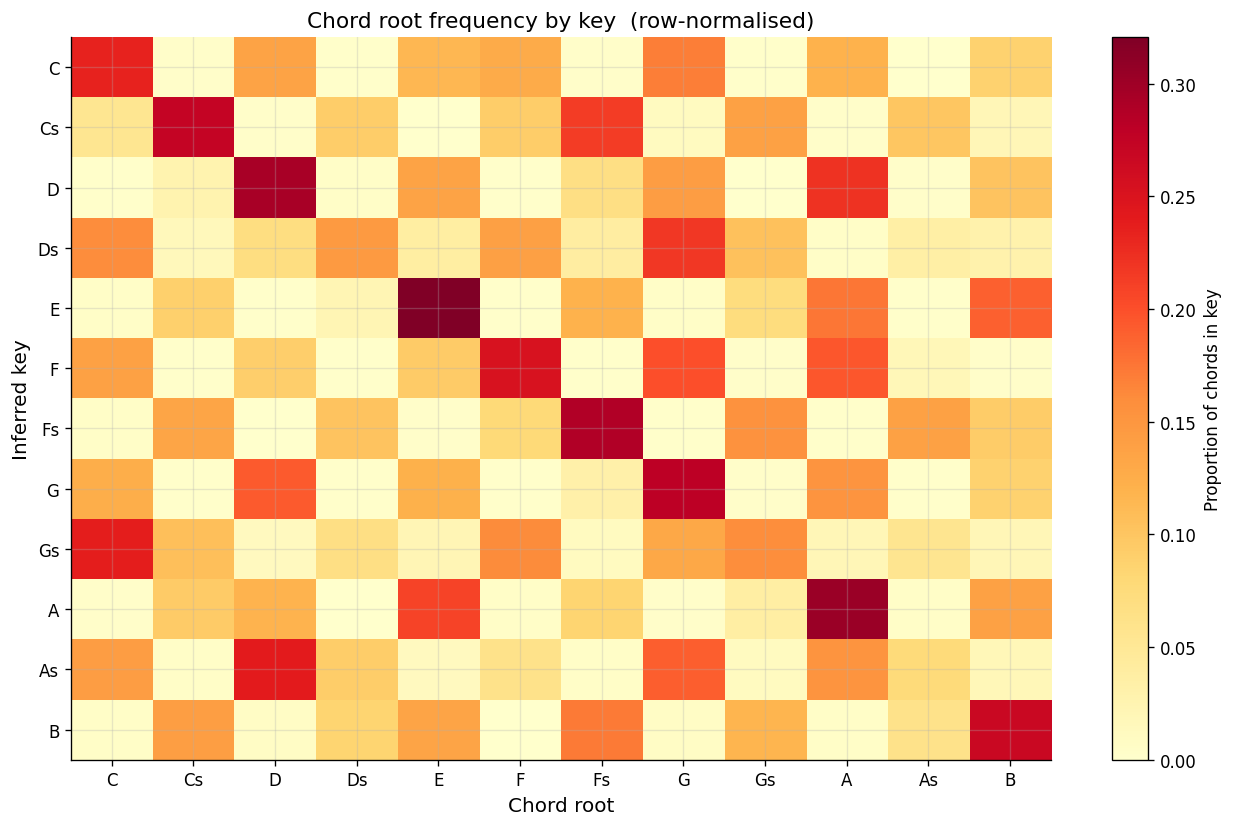

In [ ]:
rows = []
for cs in df["chords"].dropna():
    tokens = strip_structural_tags(cs)
    key_idx = infer_key(tokens)
    if key_idx is None:
        continue
    key_name = NOTES[key_idx]
    for t in tokens:
        root = parse_chord_root(t)
        if root is not None:
            rows.append({"key": key_name, "root": NOTES[root]})

pairs = pd.DataFrame(rows)
heatmap_data = (
    pairs.groupby(["key", "root"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=[n for n in NOTES if n in pairs["key"].unique()],
             columns=NOTES,
             fill_value=0)
)
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(heatmap_norm.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(NOTES)))
ax.set_xticklabels(NOTES, fontsize=10)
ax.set_yticks(range(len(heatmap_norm)))
ax.set_yticklabels(heatmap_norm.index, fontsize=10)
ax.set_xlabel("Chord root", fontsize=12)
ax.set_ylabel("Inferred key", fontsize=12)
ax.set_title("Chord root frequency by key  (row-normalised)", fontsize=13)
fig.colorbar(im, ax=ax, label="Proportion of chords in key")
plt.tight_layout()
plt.show()

---
## Pop music across the decades

The next cells filter to pop, build a separate 7×7 Markov transition matrix per decade,  
then track three quantities that directly affect what the chord generator produces:

| Metric | What it measures | Generator connection |
|--------|-----------------|---------------------|
| **Entropy rate H** | Bits of surprise per chord step | τ scaling target — how unpredictable the transitions are |
| **Diatonic ratio** | % of chords staying in key | How often chromatic insertions are warranted |
| **Mean progression length** | Diatonic chords per section | Informs the empirical length distribution sampled at runtime |

In [ ]:
# Stream and collect pop songs, grouped by decade
N_POP_TARGET = 8_000

print(f"Streaming to collect {N_POP_TARGET:,} pop songs…")
pop_by_decade: dict[int, list[str]] = defaultdict(list)
scanned = 0

ds_pop = load_dataset("ailsntua/Chordonomicon", split="train", streaming=True)
for row in ds_pop:
    if sum(len(v) for v in pop_by_decade.values()) >= N_POP_TARGET:
        break
    scanned += 1
    genre = (row.get("main_genre") or "").lower()
    decade = row.get("decade")
    chord_string = row.get("chords") or ""
    if "pop" not in genre or decade is None or not chord_string.strip():
        continue
    pop_by_decade[int(decade)].append(chord_string)

print(f"Scanned {scanned:,} total songs\n")
print("Pop songs collected by decade:")
for dec in sorted(pop_by_decade):
    print(f"  {dec}s: {len(pop_by_decade[dec]):,}")

Streaming to collect 8,000 pop songs…
Scanned 51,478 total songs

Pop songs collected by decade:
  1930s: 1
  1940s: 1
  1950s: 5
  1960s: 62
  1970s: 190
  1980s: 357
  1990s: 703
  2000s: 965
  2010s: 1,942
  2020s: 3,774


In [ ]:
# Build per-decade transition matrices + scalar statistics (chorus sections only)
# Treatment mirrors accumulate_song exactly:
#   - extract_section_instances splits on each <chorus_N> tag boundary
#   - key is inferred from all instances combined
#   - bigrams / diatonic counts are accumulated per instance (no cross-boundary transitions)
#   - length = first instance only
ALPHA = 1.0
MIN_SONGS = 20  # skip decades with too few songs

decade_stats: dict[int, dict] = {}

for decade in sorted(pop_by_decade):
    songs = pop_by_decade[decade]
    if len(songs) < MIN_SONGS:
        continue

    count_matrix = np.zeros((7, 7), dtype=np.float64)
    n_diatonic, n_chromatic = 0, 0
    lengths: list[int] = []

    for cs in songs:
        added, prog_len = accumulate_song(cs, count_matrix, section="chorus")
        if prog_len > 0:
            lengths.append(prog_len)

        instances = extract_section_instances(cs, "chorus")
        if not instances:
            continue
        all_tokens = [t for inst in instances for t in inst]
        key = infer_key(all_tokens)
        if key is None:
            continue
        for inst in instances:
            prev = None
            for t in inst:
                root = parse_chord_root(t)
                if root is None or root == prev:
                    continue
                if chord_to_degree(root, key) is not None:
                    n_diatonic += 1
                else:
                    n_chromatic += 1
                prev = root

    smoothed = count_matrix + ALPHA
    P = smoothed / smoothed.sum(axis=1, keepdims=True)
    pi = stationary_distribution(P)
    H = entropy_rate(P, pi)

    decade_stats[decade] = dict(
        P=P,
        entropy=H,
        diatonic_ratio=n_diatonic / max(n_diatonic + n_chromatic, 1),
        mean_length=float(np.mean(lengths)) if lengths else 0.0,
        n_songs=len(songs),
    )

decades = sorted(decade_stats)
print(f"Built stats for {len(decades)} decades: {decades}")

In [ ]:
# Line charts: entropy rate, diatonic ratio, mean chorus length
stats = [decade_stats[d] for d in decades]
H_MAX = np.log2(7)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Entropy rate
ax = axes[0]
ax.plot(decades, [s["entropy"] for s in stats], "o-", color="steelblue", lw=2, ms=7)
ax.axhline(H_MAX, ls="--", color="gray", alpha=0.5, label=f"max = log₂7 ≈ {H_MAX:.2f}")
ax.set_ylim(0, H_MAX * 1.1)
ax.set_title("Harmonic entropy  (bits / chord)", fontsize=12)
ax.set_xlabel("Decade")
ax.set_ylabel("H")
ax.legend(fontsize=8)

# Diatonic ratio
ax = axes[1]
ax.plot(decades, [s["diatonic_ratio"] * 100 for s in stats], "o-", color="coral", lw=2, ms=7)
ax.set_ylim(0, 100)
ax.set_title("Diatonic ratio  (% of chorus chords in key)", fontsize=12)
ax.set_xlabel("Decade")
ax.set_ylabel("%")

# Mean chorus length
ax = axes[2]
ax.plot(decades, [s["mean_length"] for s in stats], "o-", color="mediumpurple", lw=2, ms=7)
ax.set_title("Mean chorus length  (diatonic chords)", fontsize=12)
ax.set_xlabel("Decade")
ax.set_ylabel("Chords")

for ax in axes:
    ax.set_xticks(decades)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Pop chorus harmony across the decades", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

/var/folders/f0/ycpj5k2d6_15_whq0bn4z5x40000gn/T/ipykernel_61252/1269555750.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


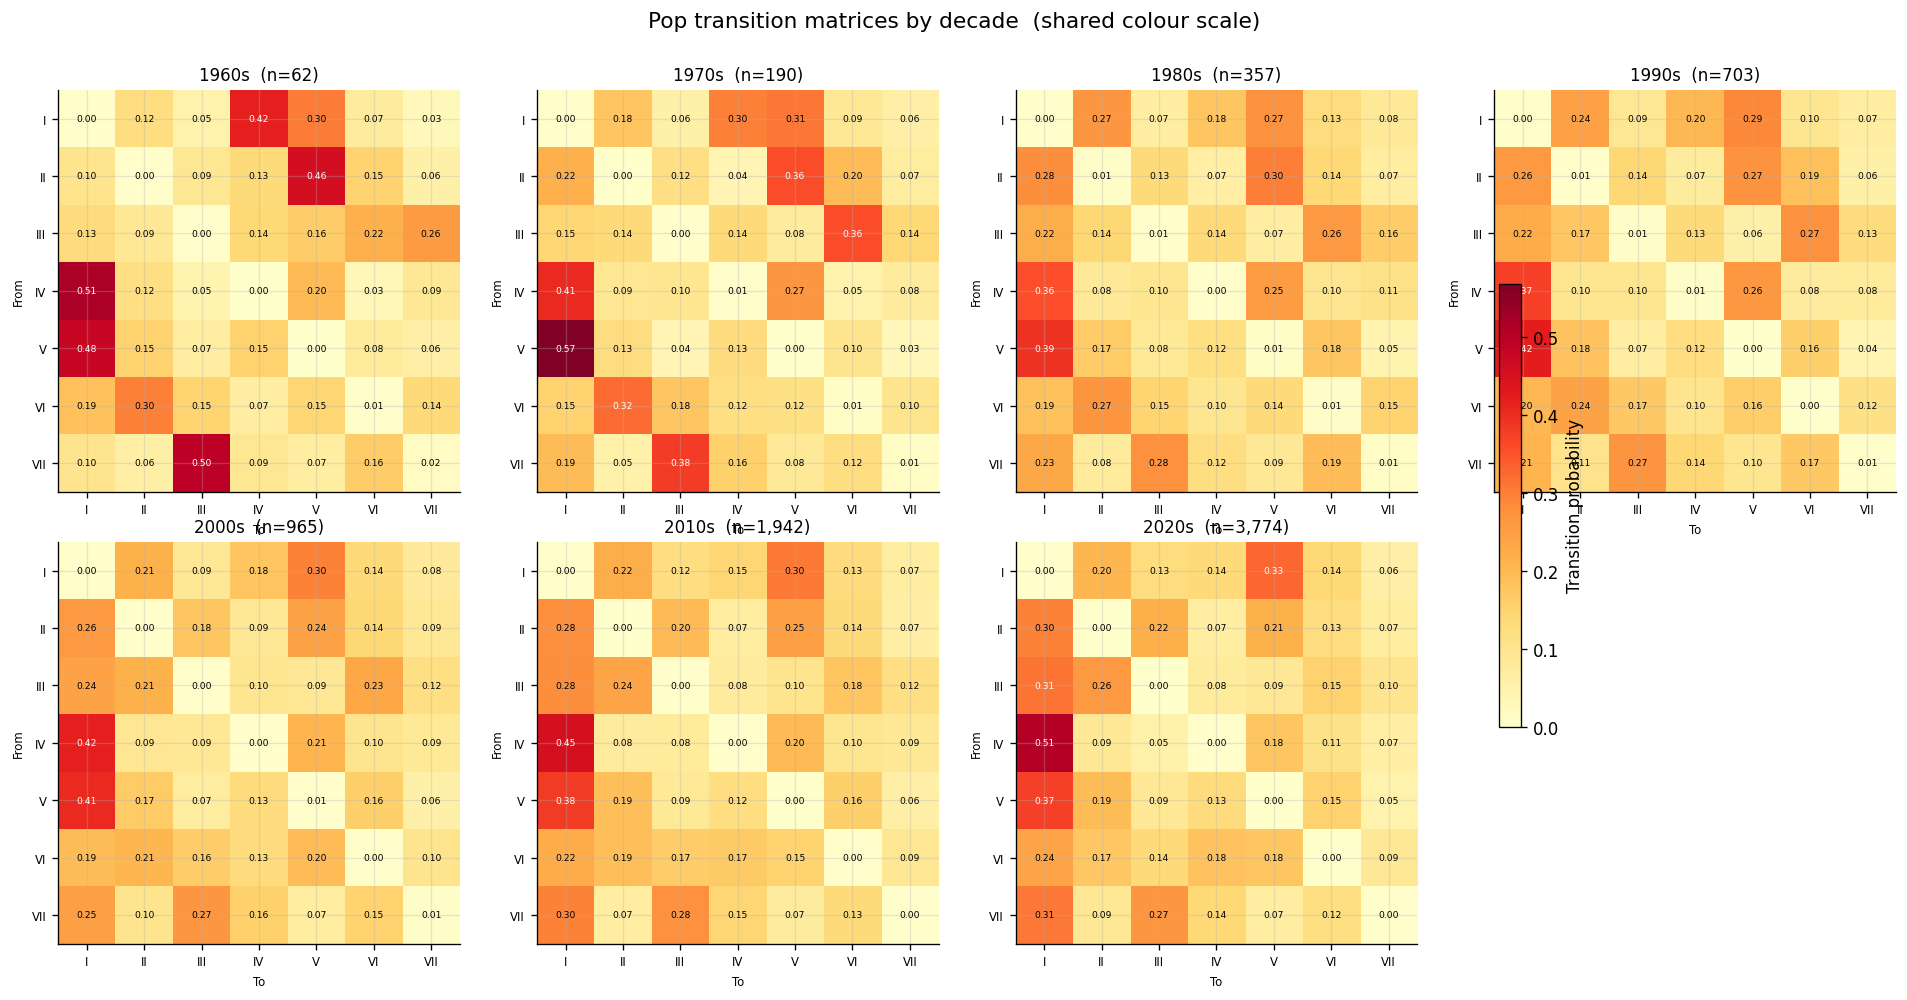

In [ ]:
# Small-multiple heatmaps: one 7×7 transition matrix per decade
# Shared colour scale so cells are comparable across decades
n_dec = len(decades)
ncols = min(4, n_dec)
nrows = (n_dec + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes_flat = np.array(axes).reshape(-1)

p_global_max = max(decade_stats[d]["P"].max() for d in decades)
thresh = p_global_max * 0.55

for i, decade in enumerate(decades):
    ax = axes_flat[i]
    P = decade_stats[decade]["P"]
    im = ax.imshow(P, cmap="YlOrRd", vmin=0, vmax=p_global_max)
    ax.set_xticks(range(7))
    ax.set_yticks(range(7))
    ax.set_xticklabels(DEGREE_NAMES, fontsize=7)
    ax.set_yticklabels(DEGREE_NAMES, fontsize=7)
    ax.set_title(f"{decade}s  (n={decade_stats[decade]['n_songs']:,})", fontsize=10)
    ax.set_xlabel("To", fontsize=7)
    ax.set_ylabel("From", fontsize=7)
    for r in range(7):
        for c in range(7):
            v = P[r, c]
            ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                    fontsize=5.5, color="white" if v >= thresh else "black")

for ax in axes_flat[n_dec:]:
    ax.set_visible(False)

fig.colorbar(im, ax=axes_flat[:n_dec].tolist(), shrink=0.6,
             label="Transition probability")
plt.suptitle("Pop transition matrices by decade  (shared colour scale)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

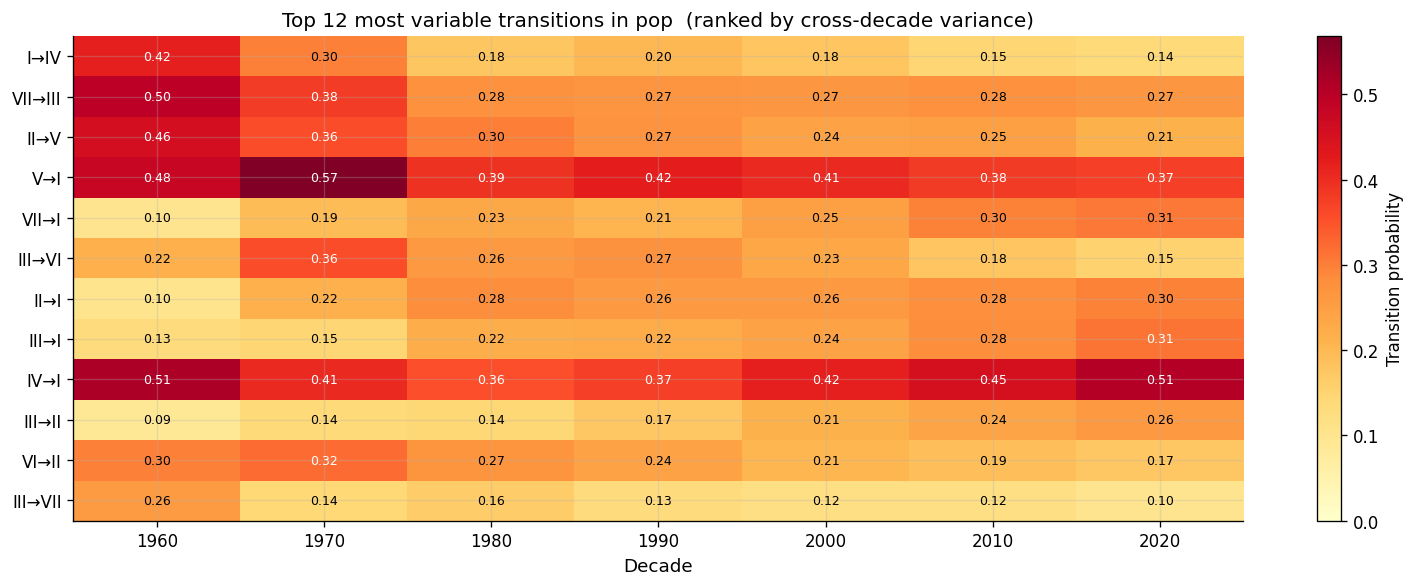

In [ ]:
# Most variable transitions across decades
# Finds which specific degree-to-degree moves changed the most — ranked by variance.
bigram_labels = [f"{DEGREE_NAMES[i]}→{DEGREE_NAMES[j]}"
                 for i in range(7) for j in range(7)]

bigram_matrix = np.array([decade_stats[d]["P"].flatten() for d in decades])  # (n_dec, 49)

TOP_N = 12
top_idx = np.argsort(bigram_matrix.var(axis=0))[::-1][:TOP_N]
top_labels = [bigram_labels[i] for i in top_idx]
data = bigram_matrix[:, top_idx].T  # (TOP_N, n_dec)

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(data, cmap="YlOrRd", aspect="auto", vmin=0, vmax=data.max())
ax.set_xticks(range(len(decades)))
ax.set_xticklabels([str(d) for d in decades], fontsize=10)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_labels, fontsize=10)
ax.set_xlabel("Decade", fontsize=11)
ax.set_title(
    f"Top {TOP_N} most variable transitions in pop  "
    "(ranked by cross-decade variance)",
    fontsize=12,
)
fig.colorbar(im, ax=ax, label="Transition probability")

for i in range(len(decades)):
    for j in range(TOP_N):
        v = data[j, i]
        ax.text(i, j, f"{v:.2f}", ha="center", va="center",
                fontsize=7.5, color="white" if v > data.max() * 0.55 else "black")

plt.tight_layout()
plt.show()